# 1 - Simple Pitch Analysis of Jazz Corpus

## Imports

In [162]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
%reload_ext autoreload
%matplotlib inline
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import io
from PIL import Image

In [166]:
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

In [168]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

## Load + Preprocess data

In [171]:
metadata = g.load_metadata()
metadata = metadata[metadata['recording_year'] >= 1950] # Filter outliers

In [173]:
notes = g.load_notes(metadata, keys=True)

In [174]:
notes_C = pa.transpose_to_C(notes)

In [175]:
notes_C = notes_C[notes_C['transposed note'].notna()]

In [232]:
bins = np.arange(1950, 2040, 20) 
bin_labels = [f"{start}-{start+20}" for start in bins[:-1]]

subset_year = notes_C[notes_C['recording_year'].notna()].copy()
subset_year['year_bin'] = pd.cut(subset_year['recording_year'], bins=bins, labels=bin_labels, right=False)

In [234]:
subset_year.groupby('year_bin').size()

year_bin
1950-1970    59640
1970-1990    19520
1990-2010    22379
2010-2030    31071
dtype: int64

In [236]:
bin_labels

['1950-1970', '1970-1990', '1990-2010', '2010-2030']

## Pitch Plots

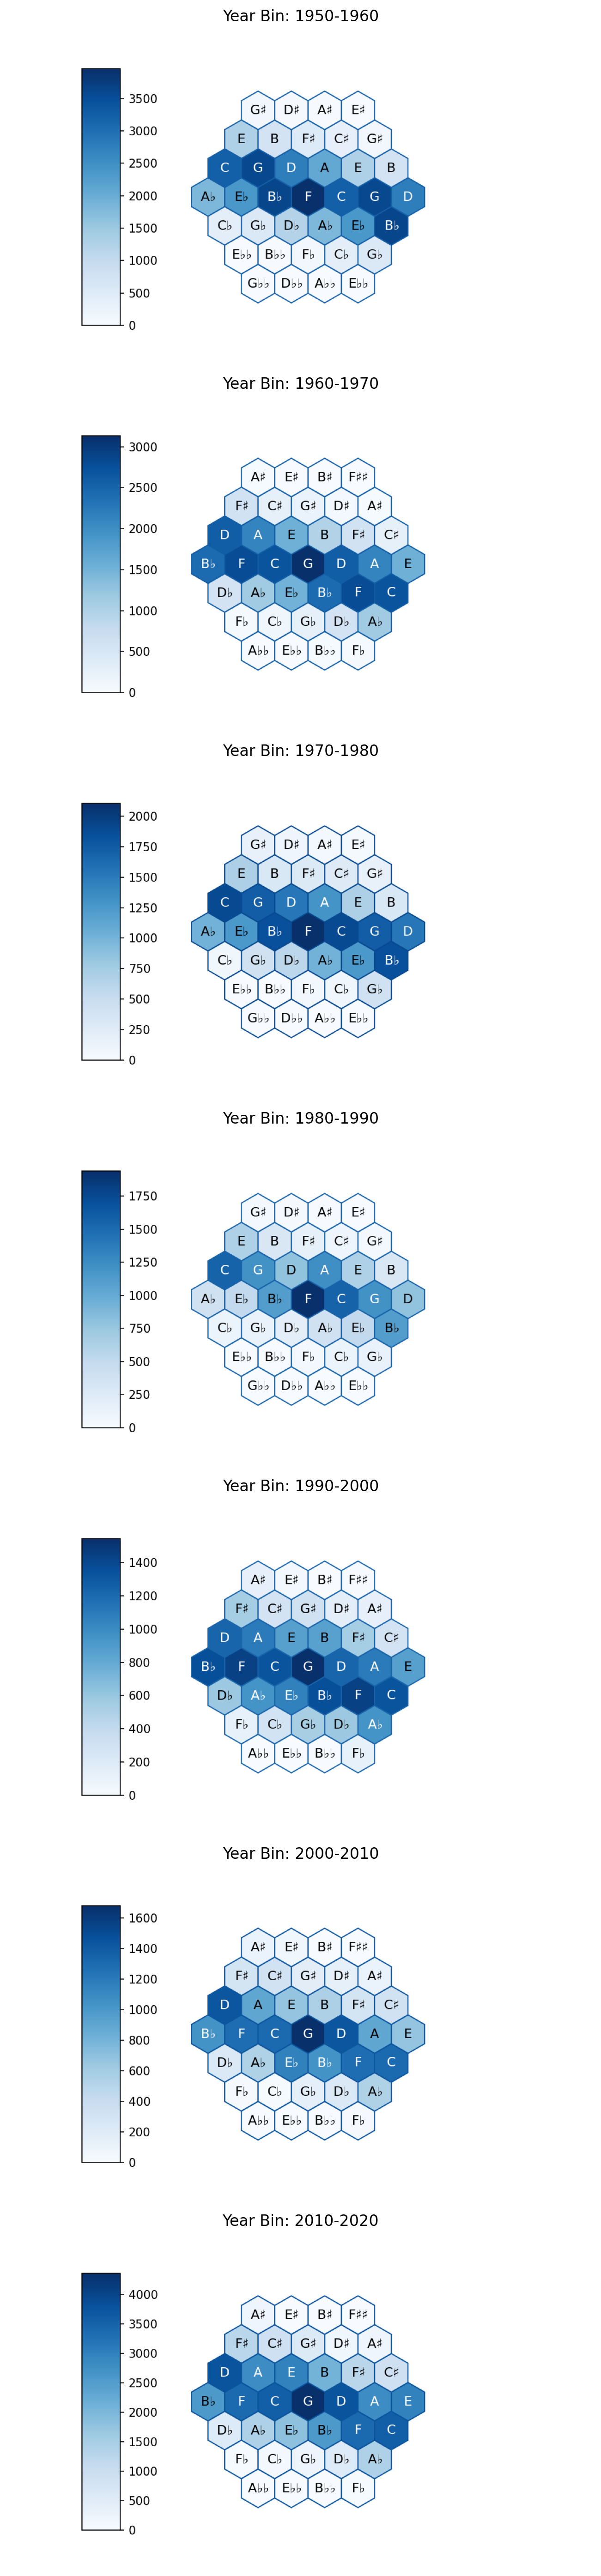

In [126]:
n_bins = len(bin_labels)
fig, axes = plt.subplots(n_bins, 1, figsize=(7, n_bins * 4))
if n_bins == 1:
    axes = [axes]  

for ax, years in zip(axes, bin_labels):
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try:
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = f"{base_path}{row['rel_paths']}/{row['fnames']}.xml"

            df = ppp.xml_to_csv(path, save_csv=False)
            notes_tonnetz = pd.concat([notes_tonnetz, df], ignore_index=True)

        except Exception:
            continue

    notes_tonnetz = notes_tonnetz.dropna(subset=['tpc'])
    notes_tonnetz['tpc'] = (notes_tonnetz['tpc'].str.replace('x', '##'))

    fig_tmp = pps.tonnetz(notes_tonnetz, show=False)

    buf = io.BytesIO()
    fig_tmp.savefig(buf, format='png', dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Year Bin: {years}", fontsize=12)

plt.tight_layout()
plt.savefig("all_tonnetz.png", dpi=300)
plt.show()


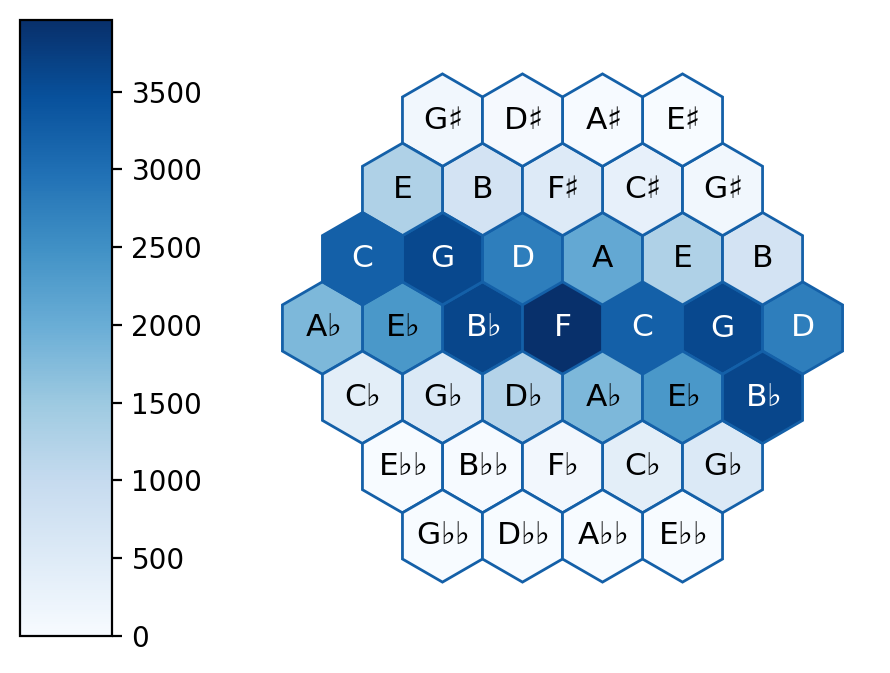

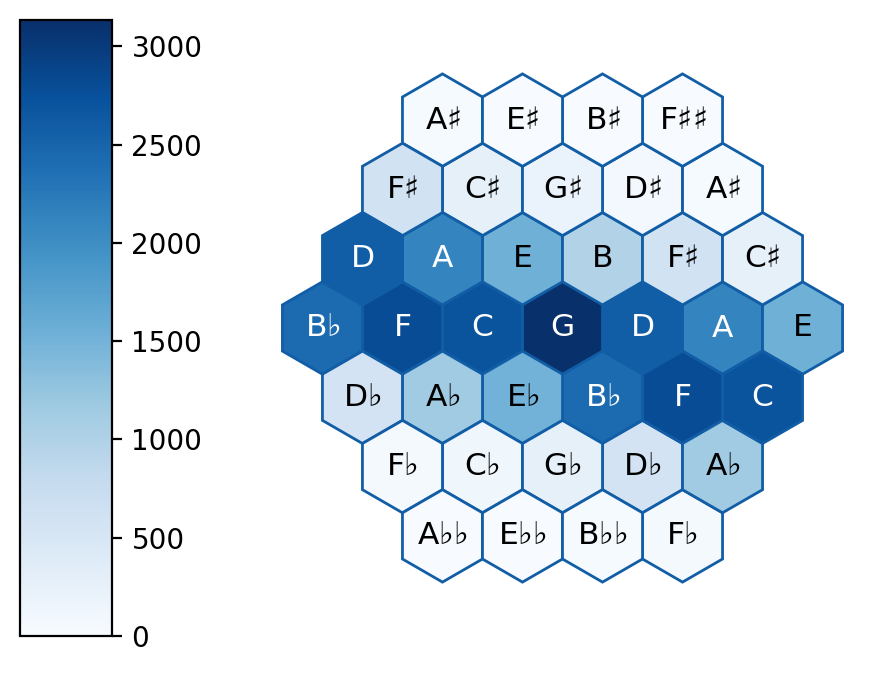

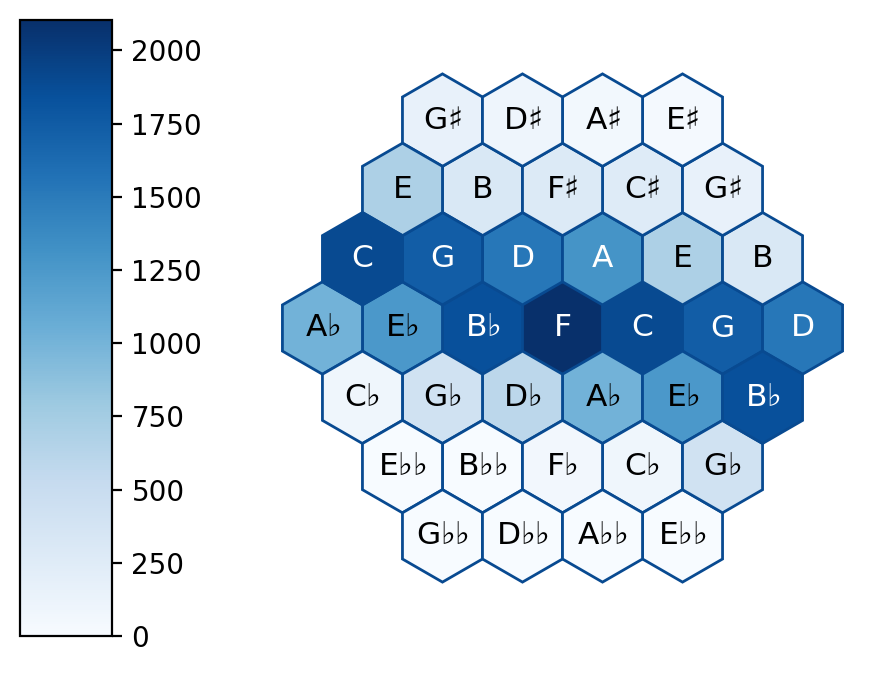

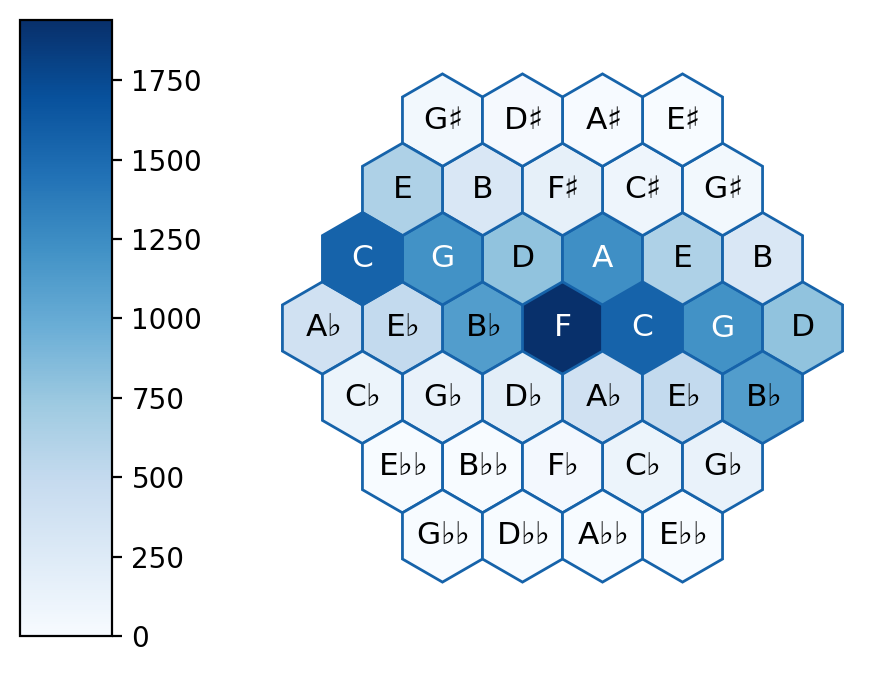

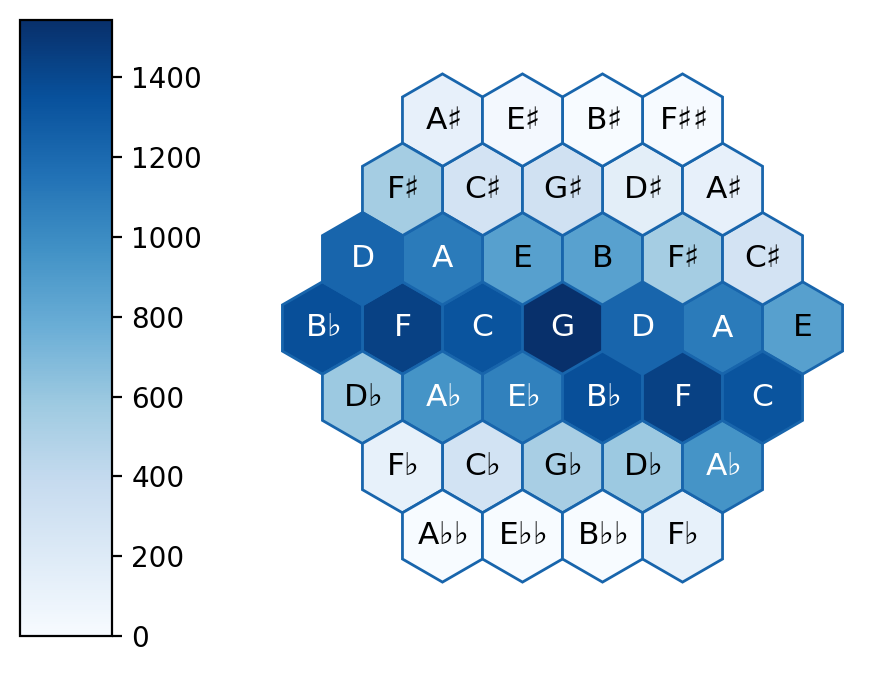

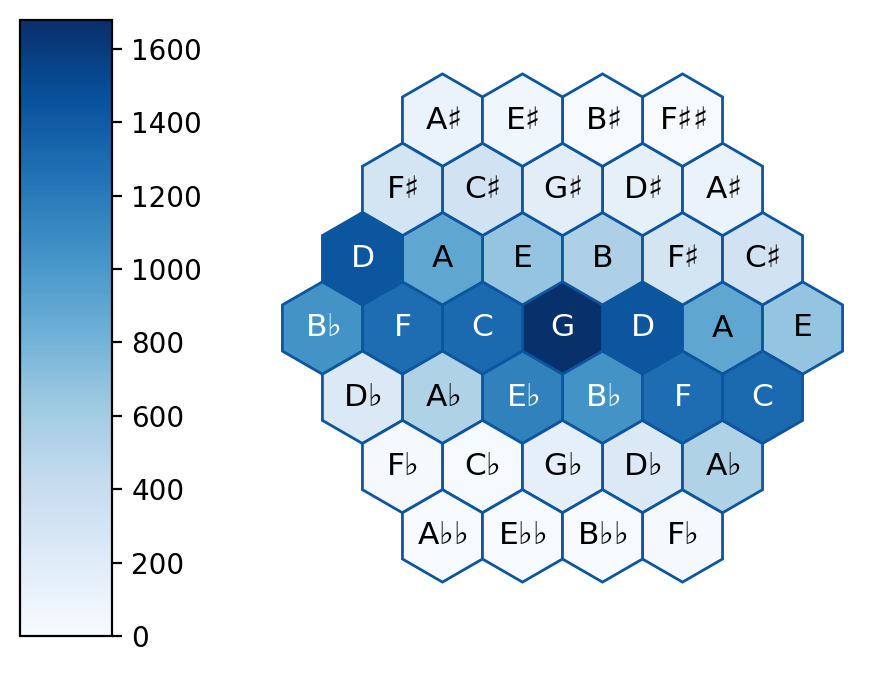

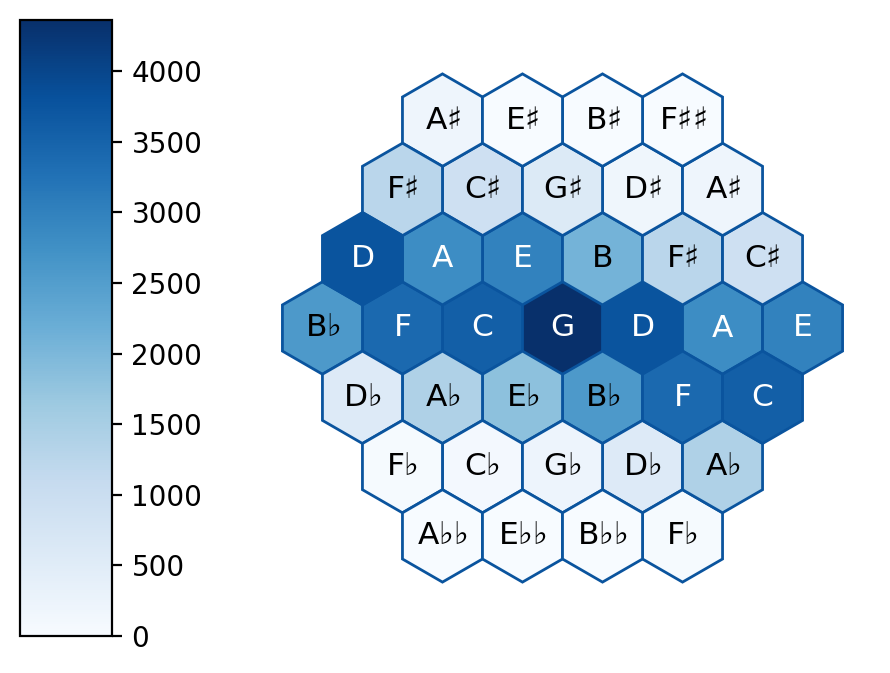

In [67]:
import pitchplots.parser as ppp
import pitchplots.static as pps

for years in bin_labels:
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try: 
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = base_path + row['rel_paths'] + '/' + row['fnames'] + '.xml'

            df = ppp.xml_to_csv(path, save_csv=False)
            notes_tonnetz = pd.concat([notes_tonnetz, df], ignore_index=True)
        except:
            continue

    notes_tonnetz = notes_tonnetz[notes_tonnetz['tpc'].notnull()]
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('x', '##'))

    fig = pps.tonnetz(notes_tonnetz, show=True)
    fig.show()
    

### Pitch plots transposed to C

In [116]:
n_bins = len(bin_labels)
fig, axes = plt.subplots(n_bins, 1, figsize=(7, n_bins * 4))
if n_bins == 1:
    axes = [axes] 

for ax, years in zip(axes, bin_labels):
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try:
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = f"{base_path}{row['rel_paths']}/{row['fnames']}.xml"

            df = ppp.xml_to_csv(path, save_csv=False)
            score = m21.converter.parse(path)
            key = score.analyze('key')
            interval_to_c = m21.interval.Interval(key.tonic, m21.pitch.Pitch('C'))

            df['tpc'] = df['tpc'].str.replace('bb', '--', regex=False)
            df['tpc'] = df['tpc'].apply(lambda n: m21.note.Note(n) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.transpose(interval_to_c) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.nameWithOctave if pd.notna(n) else np.nan)

            notes_tonnetz = pd.concat([notes_tonnetz, df[['tpc']]], ignore_index=True)
        except Exception:
            continue

    notes_tonnetz = notes_tonnetz.dropna(subset=['tpc'])
    notes_tonnetz['tpc'] = (notes_tonnetz['tpc']
        .str.replace('-', 'b')
        .str.replace('--', 'bb')
        .str.replace('---', 'bbb')
        .str.replace('x', '##'))

    fig_tmp = pps.tonnetz(notes_tonnetz, show=False)

    buf = io.BytesIO()
    fig_tmp.savefig(buf, format='png', dpi=150)
    buf.seek(0)
    img = Image.open(buf)

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Year Bin: {years}", fontsize=12)

plt.tight_layout()
plt.savefig("all_tonnetz.png", dpi=300)
plt.show()




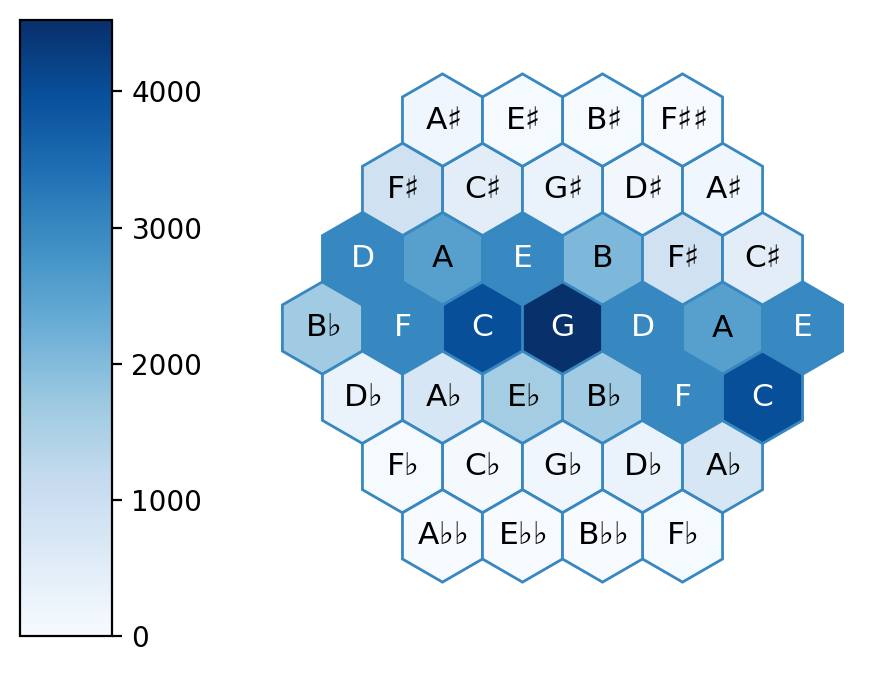

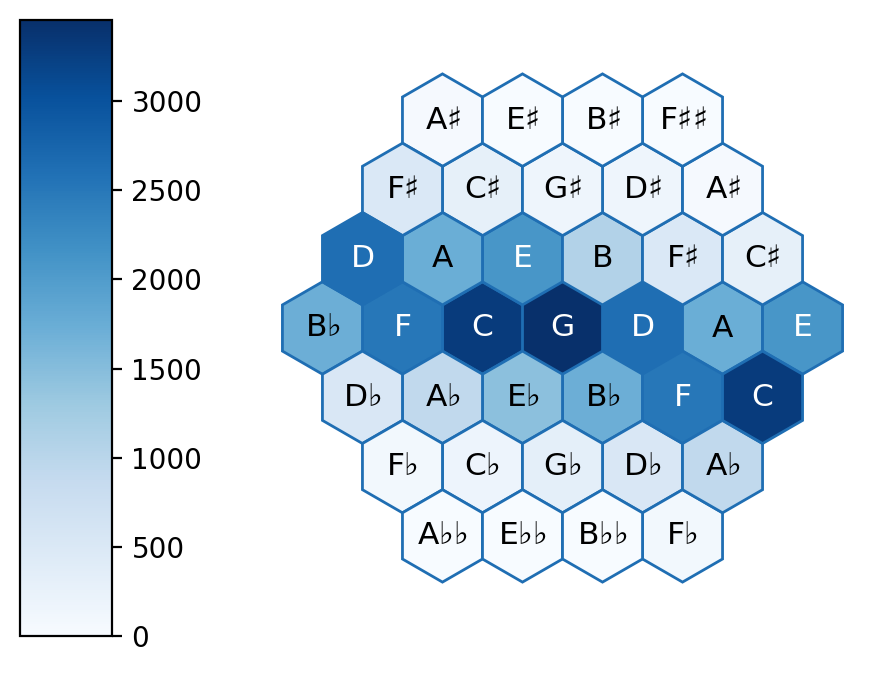

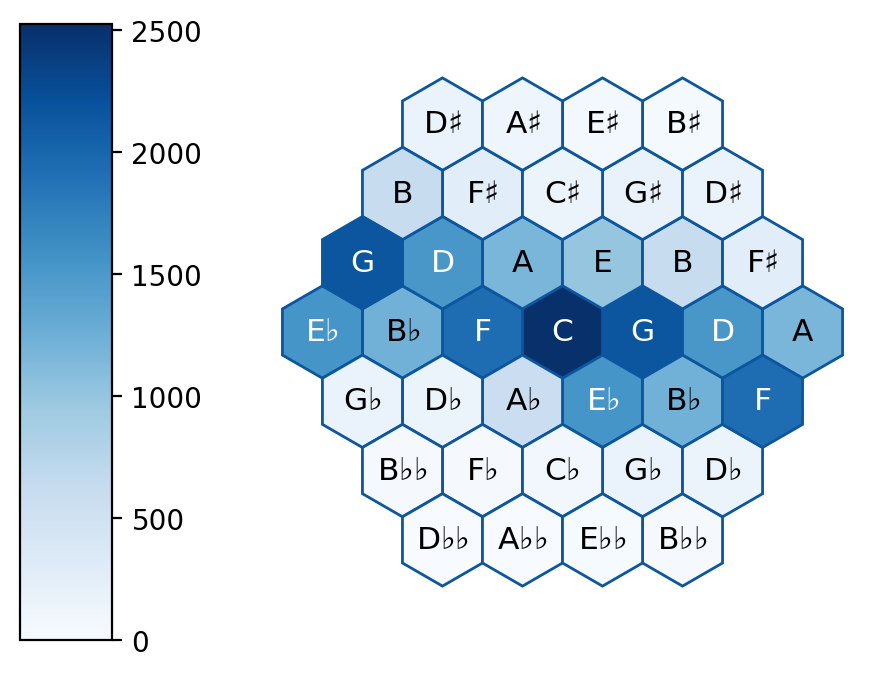

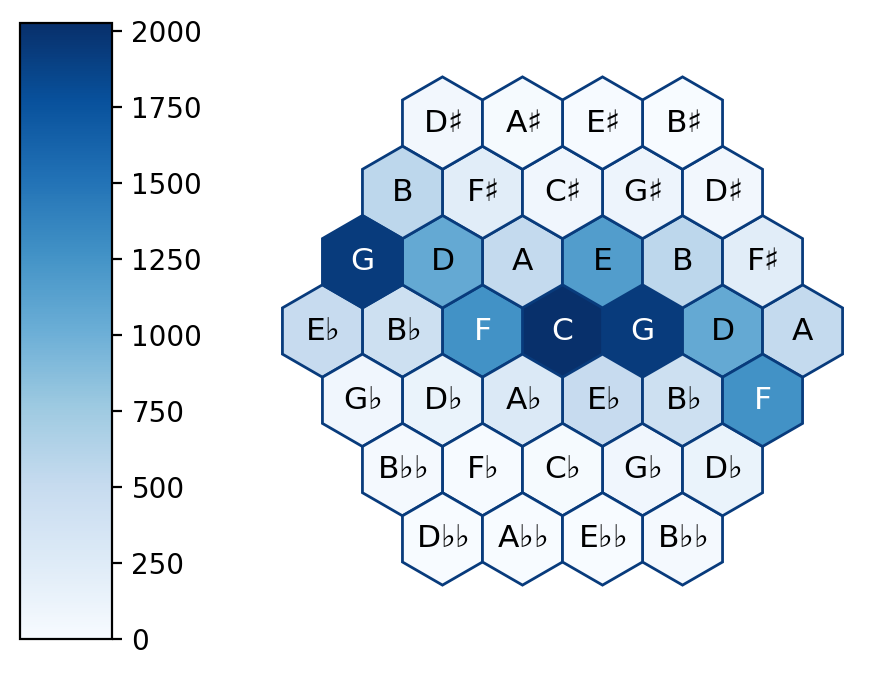

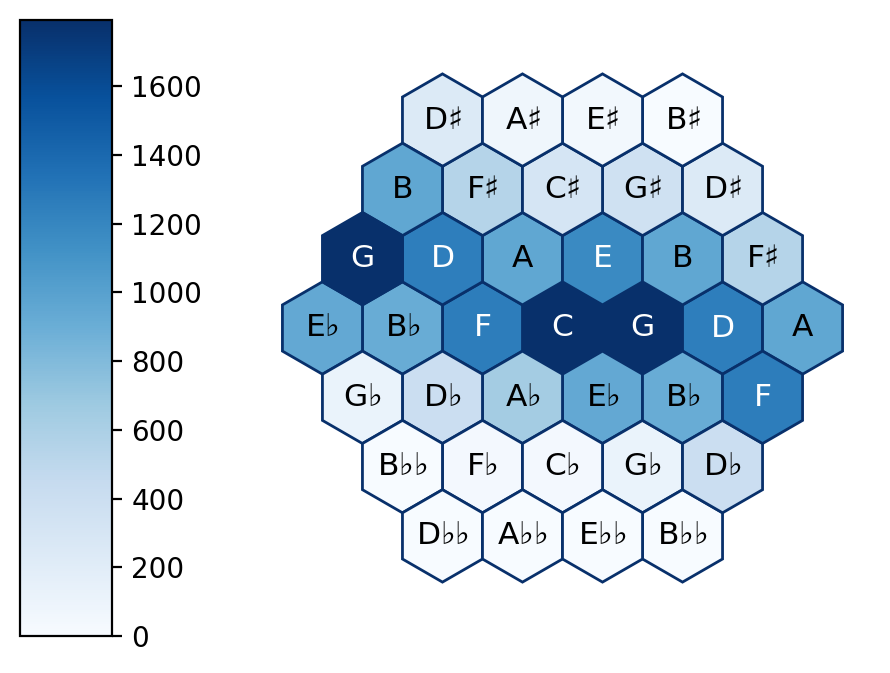

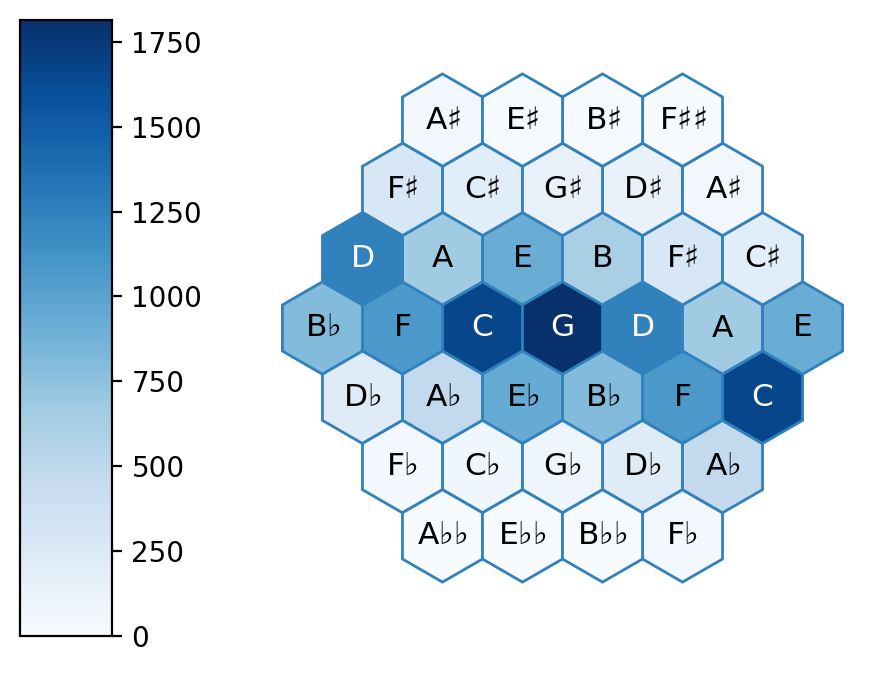

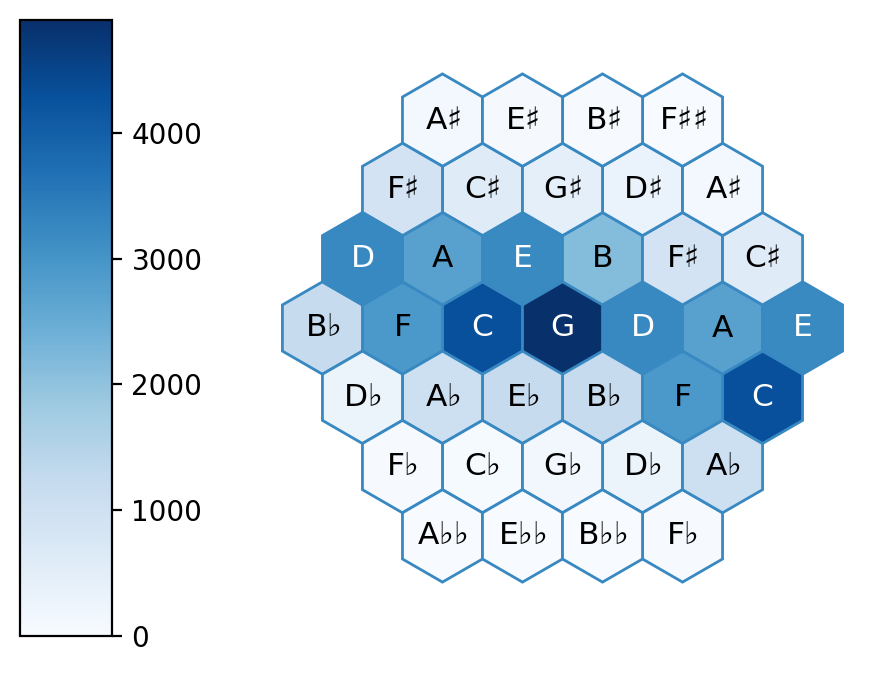

In [109]:

for years in bin_labels:
    notes_tonnetz = pd.DataFrame()
    df_years = metadata[metadata['year_bin'] == years]

    for _, row in df_years.iterrows():
        try: 
            base_path = '/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/jazz_transcriptions/' 
            path = base_path + row['rel_paths'] + '/' + row['fnames'] + '.xml'

            
            df = ppp.xml_to_csv(path, save_csv=False)

            score = m21.converter.parse(path)
            key = score.analyze('key')
            interval_to_c = m21.interval.Interval(key.tonic, m21.pitch.Pitch('C'))

            df['tpc'] = df['tpc'].str.replace('bb', '--', regex=False)
            df['tpc'] = df['tpc'].str.replace('bb', '--', regex=False)
            df['tpc'] = df['tpc'].apply(lambda n: m21.note.Note(n) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.transpose(interval_to_c) if pd.notna(n) else np.nan)
            df['tpc'] = df['tpc'].apply(lambda n: n.nameWithOctave if pd.notna(n) else np.nan)
            
            notes_tonnetz = pd.concat([notes_tonnetz, df[['tpc']]], ignore_index=True)
        except Exception as e:
            #print(f'{e}')
            continue

    notes_tonnetz = notes_tonnetz[notes_tonnetz['tpc'].notnull()]
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('-', 'b'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('--', 'bb'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('---', 'bbb'))
    notes_tonnetz['tpc'] = notes_tonnetz['tpc'].apply(lambda note: note.replace('x', '##'))

    fig = pps.tonnetz(notes_tonnetz, show=True)
    fig.show()

## By Year

In [238]:
identifier = ['year_bin']
subset_year = subset_year.groupby(identifier, as_index=False).agg(list)

In [240]:
data_year = pa.create_data(subset_year, identifier)

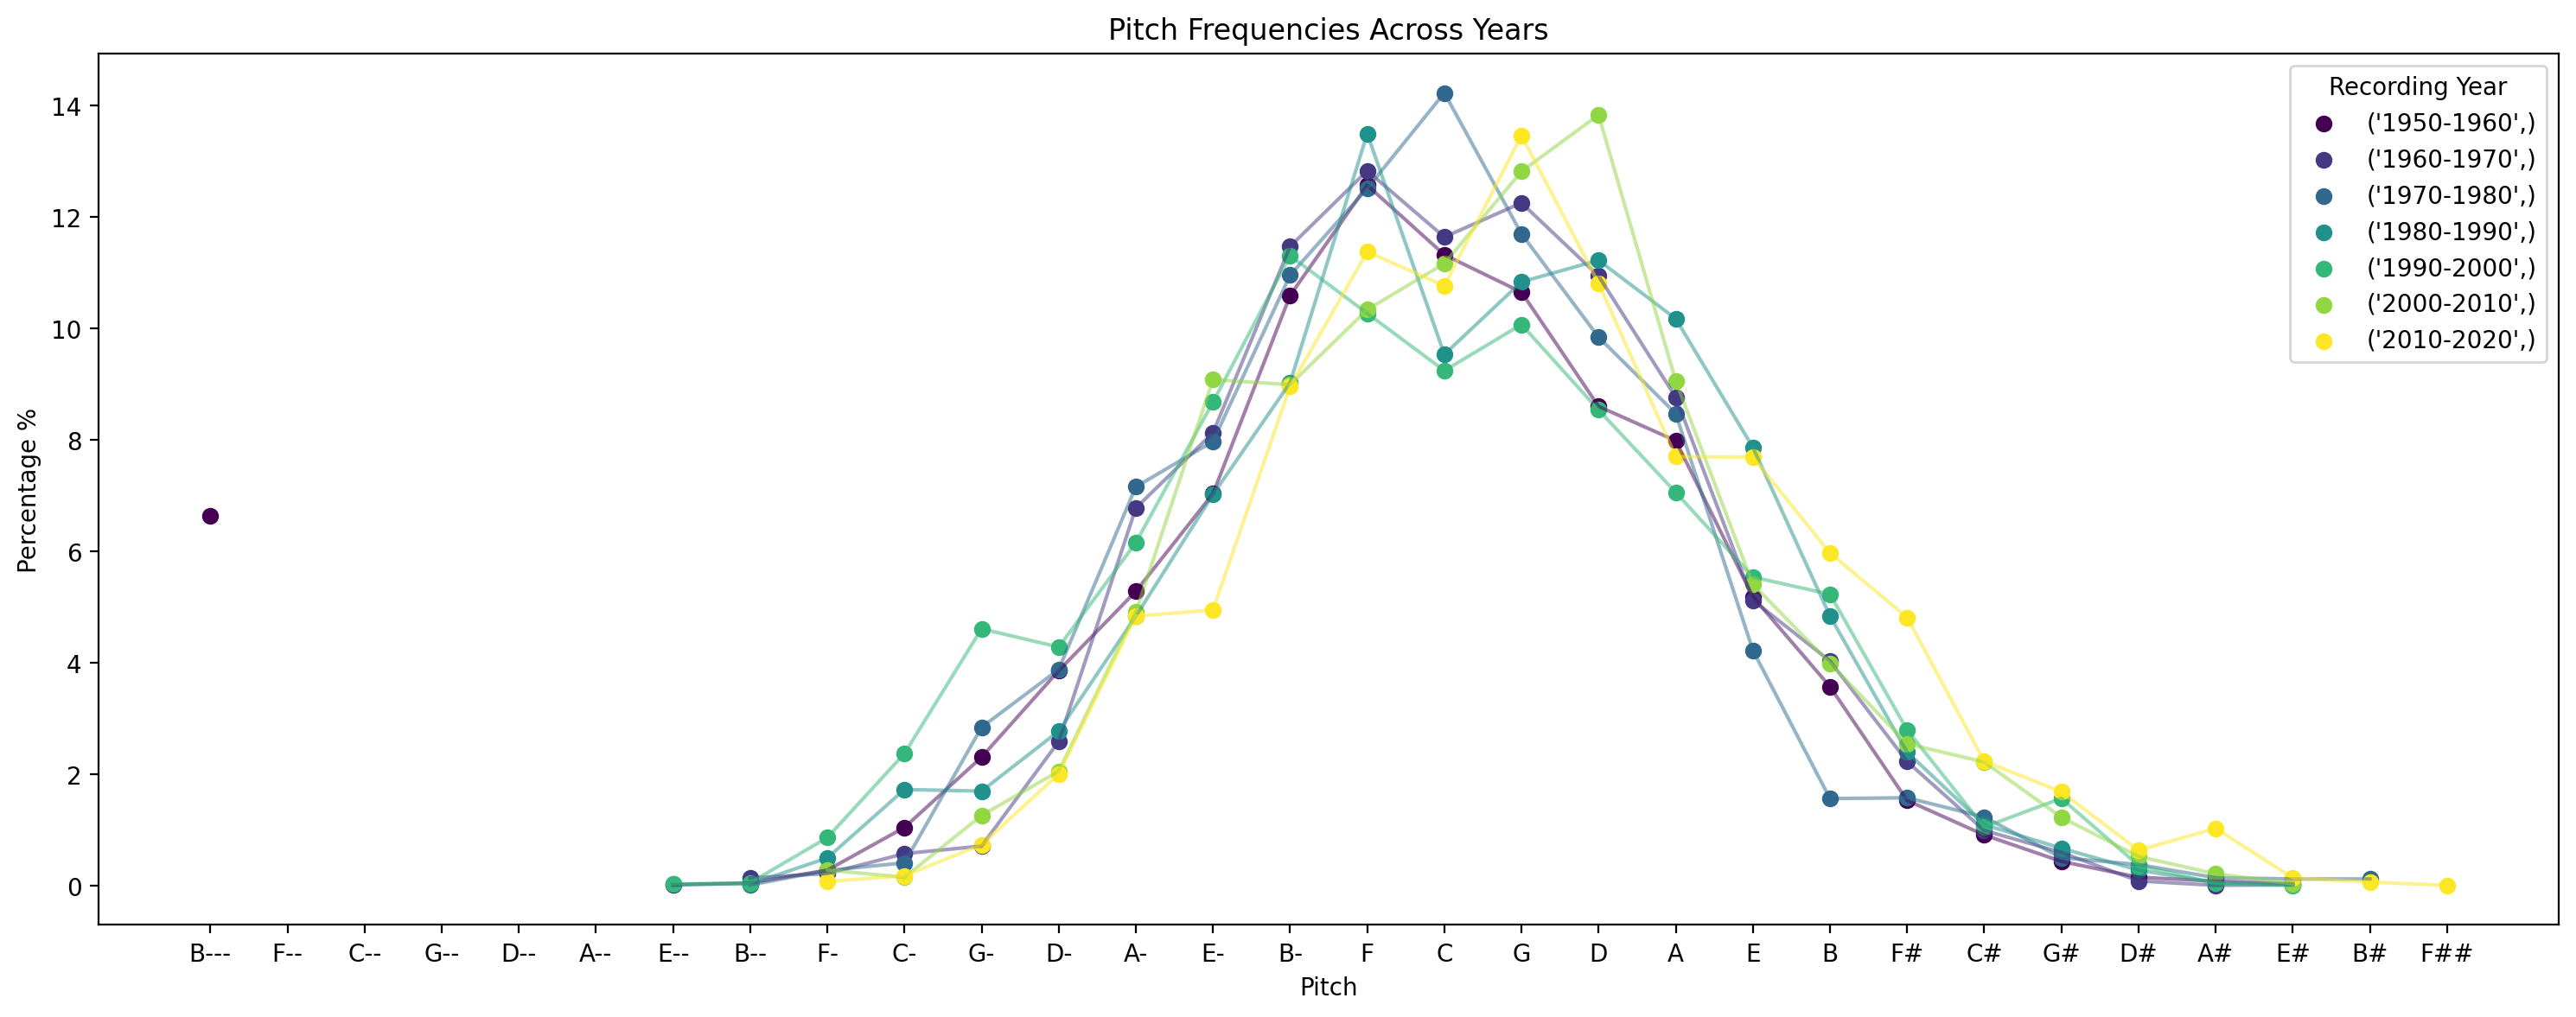

In [211]:
full_range = pd.DataFrame({
    'tpc': range(
        int(notes_C['tpc'].min()),
        int(notes_C['tpc'].max()) + 1  # include max
    )
})

keys = list(data_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors

for i, key in enumerate(keys):

    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'note': pitch_data['note'],
        'tpc': pitch_data['tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['note', 'tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    count = full_range.merge(count, on='tpc', how='left')
    count['note'] = count['tpc'].apply(pa.get_note)

    ax.plot(count['note'], count['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(count['note'],count['percentage'], label=key, color=colors(i))

ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Pitch Frequencies Across Years')
ax.legend(title='Recording Year')

plt.tight_layout()
plt.savefig(f"../Results/0823_YearPitchOverlay")
plt.show()

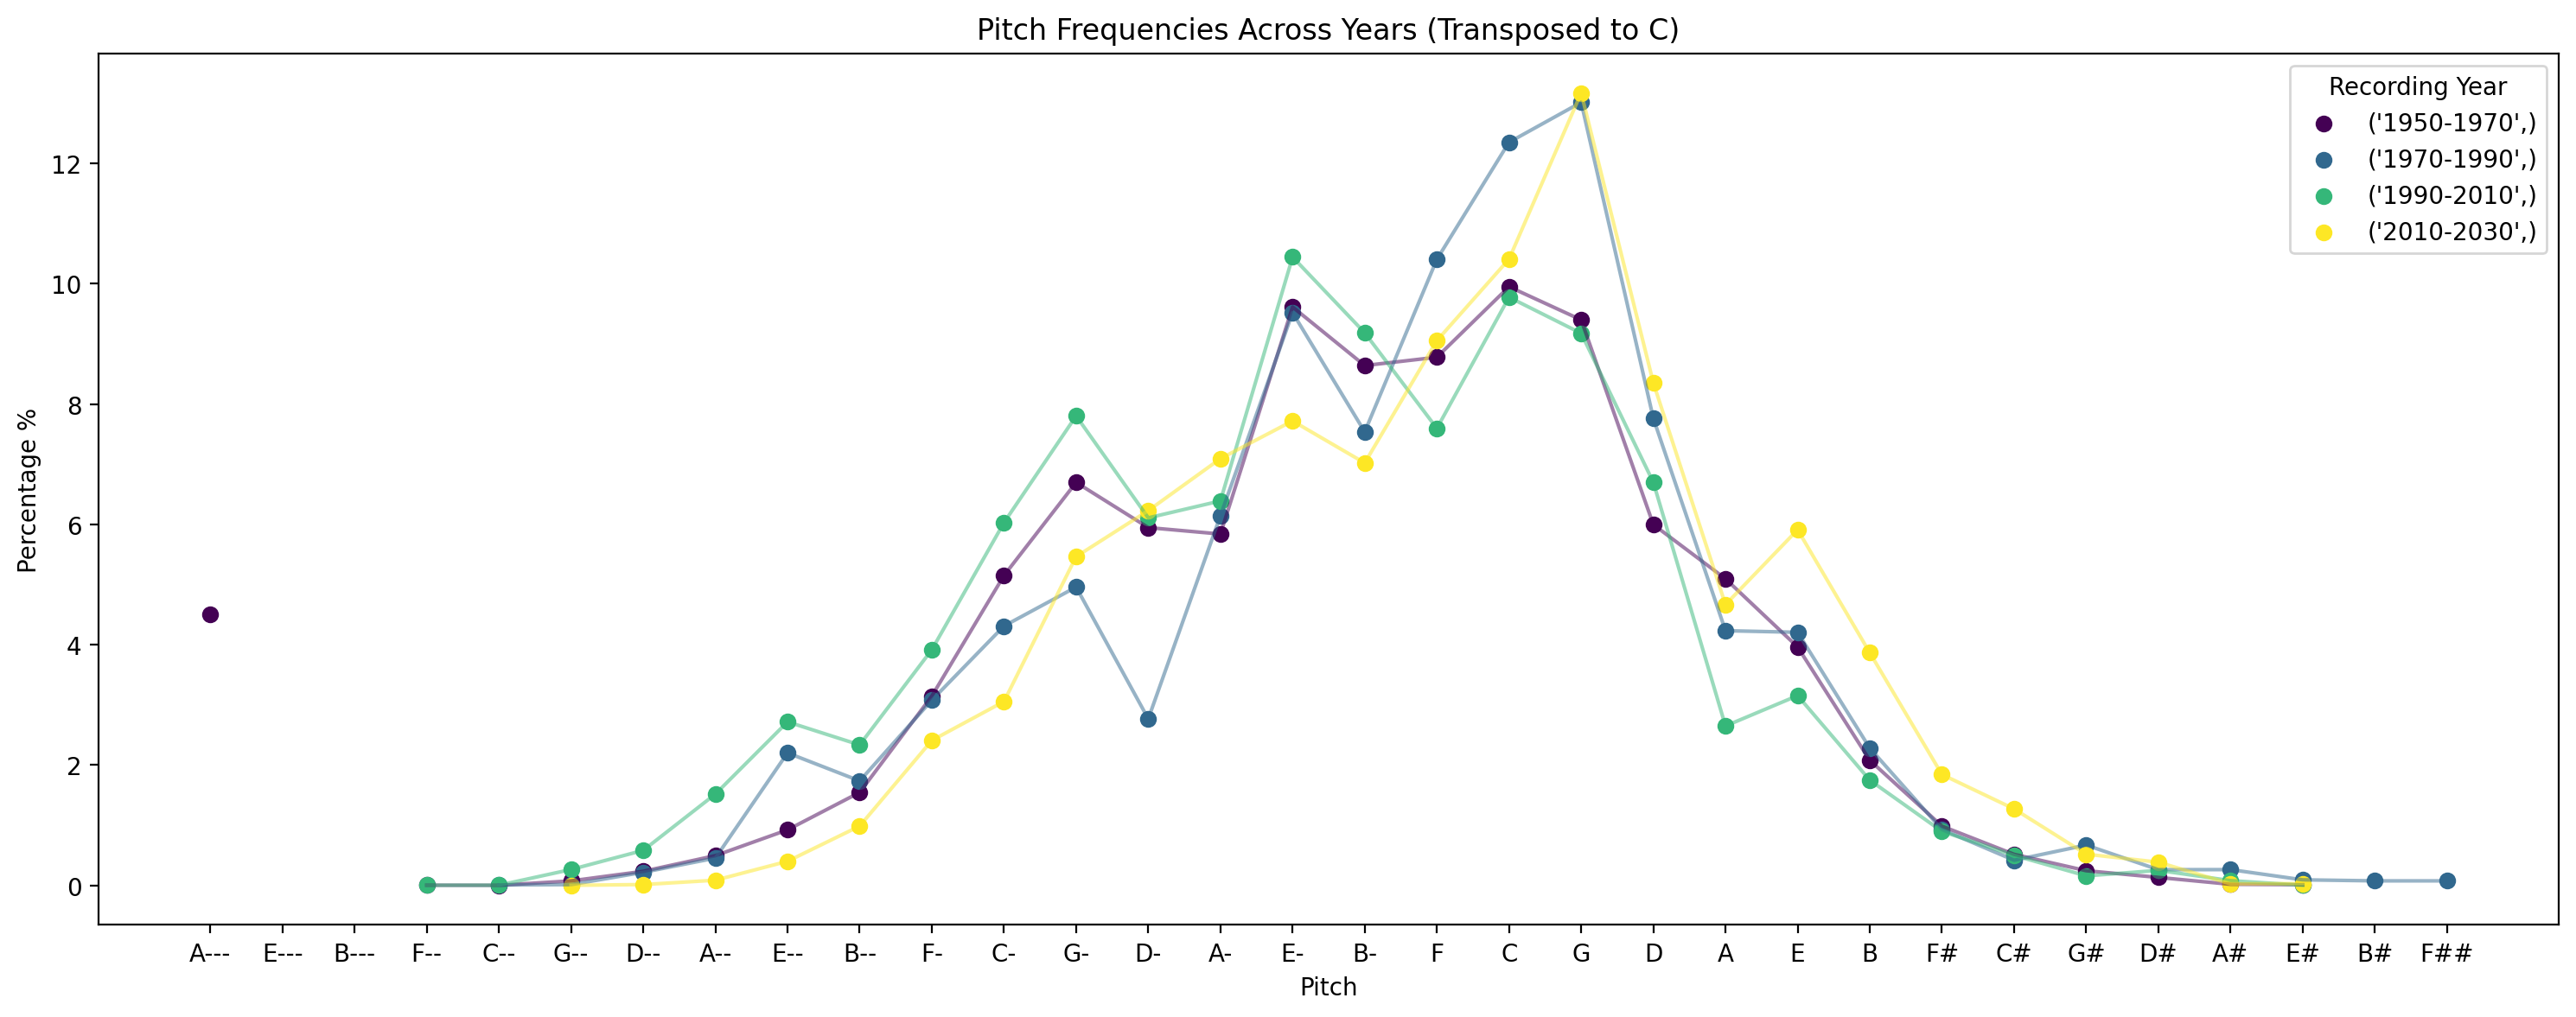

In [242]:
full_range = pd.DataFrame({
    'transposed tpc': range(
        int(notes_C['transposed tpc'].min()),
        int(notes_C['transposed tpc'].max()) + 1  # include max
    )
})

keys = list(data_year.keys())

fig, ax = plt.subplots(figsize=(15, 6))  # One figure and one axis

colors = plt.cm.get_cmap('viridis', len(keys))  # Distinct colors

for i, key in enumerate(keys):

    # Get the pitch profile data
    pitch_data = data_year[key]
    tpc = pd.DataFrame({
        'transposed note': pitch_data['transposed note'],
        'transposed tpc': pitch_data['transposed tpc'],
        'duration': pitch_data['duration']
    })

    pitch_counts = tpc.groupby(['transposed note', 'transposed tpc'])['duration'].sum().reset_index(name='weighted_count')
    count = pitch_counts.sort_values('transposed tpc')
    total = count['weighted_count'].sum()
    count['percentage'] = (count['weighted_count'] / total)*100

    count = full_range.merge(count, on='transposed tpc', how='left')
    count['transposed note'] = count['transposed tpc'].apply(pa.get_note)

    ax.plot(count['transposed note'], count['percentage'], color=colors(i), alpha=0.5)
    ax.scatter(count['transposed note'],count['percentage'], label=key, color=colors(i))

ax.set_xlabel('Pitch')
ax.set_ylabel('Percentage %')
ax.set_title(f'Pitch Frequencies Across Years (Transposed to C)')
ax.legend(title='Recording Year')

plt.tight_layout()
#plt.savefig(f"../Results/0823_YearTransposedPitchOverlay")
plt.show()